Admission Number: CCS/00099/022

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

df = pd.read_csv(
    'twitter_training.csv',
    header=None,
    names=['id', 'entity', 'sentiment', 'text'],
    usecols=[0, 1, 2, 3],
    engine='python',
    on_bad_lines='skip'
)

df = df.dropna(subset=['text', 'sentiment']).copy()
df['text'] = df['text'].astype(str)
df['sentiment'] = df['sentiment'].astype(str)

print('Loaded rows:', len(df))
print(df['sentiment'].value_counts())

Loaded rows: 73996
sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


In [13]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 2]
    return tokens

df['tokens'] = df['text'].apply(preprocess_text)
df = df[df['tokens'].map(len) > 0].reset_index(drop=True)
df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))

print('Rows after preprocessing:', len(df))
print(df[['text', 'tokens']].head(2))

Rows after preprocessing: 72161
                                                text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   

                           tokens  
0  [getting, borderlands, murder]  
1         [coming, borders, kill]  


In [14]:
tokenized = df['tokens'].tolist()
split_idx = int(0.8 * len(tokenized))
base_sentences = tokenized[:split_idx]
additional_sentences = tokenized[split_idx:]

model = Word2Vec(
    sentences=base_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10
)

if len(additional_sentences) > 0:
    model.build_vocab(additional_sentences, update=True)
    model.train(additional_sentences, total_examples=len(additional_sentences), epochs=5)

model.save('word2vec.model')
print('Vocabulary size:', len(model.wv.key_to_index))

Vocabulary size: 21568


In [15]:
from collections import Counter
all_tokens = [tok for row in df['tokens'] for tok in row]
freq = Counter(all_tokens).most_common(300)
top_words = [w for w, _ in freq if w in model.wv.key_to_index][:150]
print('Top words available for PCA:', len(top_words))

Top words available for PCA: 150


In [16]:
words_to_check = ['game', 'borderlands', 'overwatch', 'love', 'amazon']
for word in words_to_check:
    print(f'\nMost similar to {word}:')
    if word in model.wv.key_to_index:
        similar = model.wv.most_similar(word, topn=5)
        for w, score in similar:
            print(f'  {w}: {score:.4f}')
    else:
        print('  not in vocabulary')


Most similar to game:
  stutters: 0.7261
  pete: 0.7238
  volleyball: 0.7193
  eighth: 0.7159
  desync: 0.7144

Most similar to borderlands:
  borderland: 0.6268
  dlc: 0.5866
  border: 0.5630
  isketambola: 0.5619
  sementara: 0.5456

Most similar to overwatch:
  ladybug: 0.5066
  genji: 0.4971
  cumgoblin: 0.4906
  diminished: 0.4905
  continuity: 0.4856

Most similar to love:
  tentacles: 0.5123
  assaulted: 0.5104
  smiff: 0.5104
  ooh: 0.5048
  jerseys: 0.5044

Most similar to amazon:
  smashwords: 0.6131
  liable: 0.6094
  infoapp: 0.6015
  authl: 0.6004
  submi: 0.5976


In [17]:
analogy_sets = [
    ('good', 'bad', 'great'),
    ('love', 'hate', 'like'),
    ('happy', 'sad', 'excited'),
    ('win', 'lose', 'victory'),
    ('best', 'worst', 'better')
]

for a, b, c in analogy_sets:
    print(f'\nAnalogy: {a} - {b} + {c}')
    if all(w in model.wv.key_to_index for w in [a, b, c]):
        out = model.wv.most_similar(positive=[a, c], negative=[b], topn=3)
        for w, score in out:
            print(f'  {w}: {score:.4f}')
    else:
        missing = [w for w in [a, b, c] if w not in model.wv.key_to_index]
        print('  missing words:', missing)


Analogy: good - bad + great
  andvance: 0.4935
  awesome: 0.4921
  auroa: 0.4803

Analogy: love - hate + like
  swift: 0.5002
  unfortunately: 0.4924
  mixed: 0.4774

Analogy: happy - sad + excited
  pleased: 0.5179
  phew: 0.4945
  pumped: 0.4923

Analogy: win - lose + victory
  idle: 0.5352
  empire: 0.5209
  futbal: 0.5160

Analogy: best - worst + better
  promote: 0.4232
  thel: 0.4077
  techsall: 0.3991


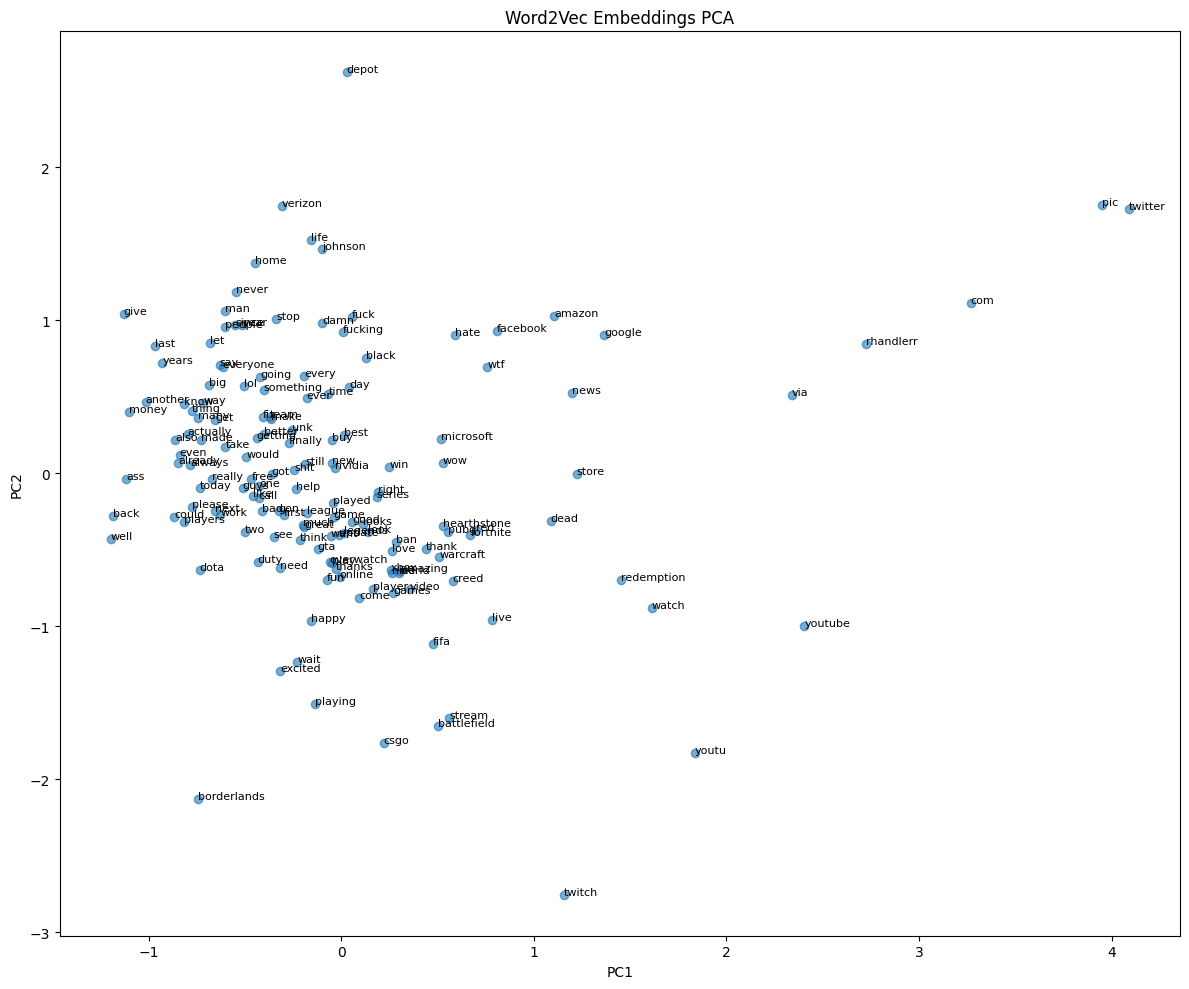

In [18]:
vectors = model.wv[top_words]
pca = PCA(n_components=2, random_state=42)
result = pca.fit_transform(vectors)

plt.figure(figsize=(12, 10))
plt.scatter(result[:, 0], result[:, 1], alpha=0.6)
for i, word in enumerate(top_words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=8)
plt.title('Word2Vec Embeddings PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

In [19]:
label_codes, uniques = pd.factorize(df['sentiment'])
df['sentiment_num'] = label_codes
y = df['sentiment_num'].values

def average_word_vectors(tokens, w2v_model, vector_size=100):
    vecs = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv.key_to_index]
    if len(vecs) == 0:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

X_avg = np.array([average_word_vectors(tokens, model) for tokens in df['tokens']])

X_train_avg, X_test_avg, y_train, y_test = train_test_split(
    X_avg, y, test_size=0.2, random_state=42, stratify=y
)

clf_avg = LogisticRegression(max_iter=1000, random_state=42)
clf_avg.fit(X_train_avg, y_train)
y_pred_avg = clf_avg.predict(X_test_avg)

acc_avg = accuracy_score(y_test, y_pred_avg)
print('Accuracy (Average Word2Vec):', acc_avg)
print(classification_report(y_test, y_pred_avg, target_names=[str(x) for x in uniques]))

Accuracy (Average Word2Vec): 0.5348853322247626
              precision    recall  f1-score   support

    Positive       0.55      0.60      0.57      4021
     Neutral       0.52      0.49      0.50      3520
    Negative       0.57      0.70      0.63      4371
  Irrelevant       0.40      0.21      0.27      2521

    accuracy                           0.53     14433
   macro avg       0.51      0.50      0.49     14433
weighted avg       0.52      0.53      0.52     14433



In [20]:
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    df['clean_text'], y, test_size=0.2, random_state=42, stratify=y
)

cv = CountVectorizer(max_features=20000)
X_train_cv = cv.fit_transform(X_train_txt)
X_test_cv = cv.transform(X_test_txt)

clf_cv = LogisticRegression(max_iter=1000, random_state=42)
clf_cv.fit(X_train_cv, y_train_txt)
y_pred_cv = clf_cv.predict(X_test_cv)
acc_cv = accuracy_score(y_test_txt, y_pred_cv)
print('Accuracy (CountVectorizer):', acc_cv)

tfidf = TfidfVectorizer(max_features=20000)
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf = tfidf.transform(X_test_txt)

clf_tfidf = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train_txt)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test_txt, y_pred_tfidf)
print('Accuracy (TF-IDF):', acc_tfidf)

Accuracy (CountVectorizer): 0.8341994041432828
Accuracy (TF-IDF): 0.7959537171759163


In [ ]:
import sys
import subprocess

try:
    from sentence_transformers import SentenceTransformer
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch', '--index-url', 'https://download.pytorch.org/whl/cpu'])
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'sentence-transformers'])
    from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
X_sbert = sbert_model.encode(df['text'].fillna('').tolist(), show_progress_bar=True)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sbert, y, test_size=0.2, random_state=42, stratify=y
)

clf_sbert = LogisticRegression(max_iter=1000, random_state=42)
clf_sbert.fit(X_train_s, y_train_s)
y_pred_sbert = clf_sbert.predict(X_test_s)

acc_sbert = accuracy_score(y_test_s, y_pred_sbert)
print('Accuracy (Sentence-Transformer):', acc_sbert)
print(classification_report(y_test_s, y_pred_sbert, target_names=[str(x) for x in uniques]))

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 MB 441.5 kB/s  0:08:350:00:0100:10
Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl (930 kB)
Using cached fsspec-2026.2.0-py3-none-any.whl (202 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached filelock-3.25.2-py3-none-any.whl (26 kB)
  Attempting uninstall: setuptools━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [s

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2256 [00:00<?, ?it/s]

In [ ]:
results = pd.DataFrame({
    'Model': [
        'CountVectorizer + LogisticRegression',
        'TF-IDF + LogisticRegression',
        'Average Word2Vec + LogisticRegression',
        'Sentence-Transformer + LogisticRegression'
    ],
    'Accuracy': [acc_cv, acc_tfidf, acc_avg, acc_sbert]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results)

plt.figure(figsize=(10, 5))
plt.bar(results['Model'], results['Accuracy'])
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()